In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor
import pickle
import warnings
warnings.filterwarnings('ignore')

def load_and_combine_data():
    """Load and combine all datasets"""
    df_main = pd.read_csv('kalimati_tarkari_dataset_cleaned.csv')
    df_secondary = pd.read_csv('kalimati-tarkari-prices-from-may-2021-to-september-2023.csv')
    df_tertiary = pd.read_csv('kalimati_prices.csv')
    
    df_tertiary['Date'] = pd.to_datetime(df_tertiary['Date'], format="%Y-%m-%d")
    combined_df = pd.concat([df_main, df_secondary, df_tertiary], ignore_index=True)
    
    return combined_df

def preprocess_data(df):
    """Clean and preprocess the data"""
    
    df = df.drop('SN', axis=1)
    df = df.drop_duplicates()
    
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['weekday'] = df['Date'].dt.day_name()
    df['quarter'] = df['Date'].dt.quarter
    df['day_of_year'] = df['Date'].dt.dayofyear
    
    def clean_price(value):
        if isinstance(value, str) and 'Rs' in value:
            value = value.replace('Rs', '').replace(',', '').strip()
            return float(value.split()[0])
        return float(value)
    
    df['average_price'] = pd.to_numeric(df['Average'].apply(clean_price), errors='coerce')
    df = df.dropna(subset=['average_price'])
    
    cleaned_df = pd.DataFrame()
    for commodity in df['Commodity'].unique():
        commodity_data = df[df['Commodity'] == commodity].copy()
        
        Q1 = commodity_data['average_price'].quantile(0.25)
        Q3 = commodity_data['average_price'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        commodity_data = commodity_data[
            (commodity_data['average_price'] >= lower_bound) & 
            (commodity_data['average_price'] <= upper_bound)
        ]
        
        cleaned_df = pd.concat([cleaned_df, commodity_data])
    
    columns_to_drop = ['Date', 'Average', 'Unit', 'Minimum', 'Maximum']
    cleaned_df = cleaned_df.drop([col for col in columns_to_drop if col in cleaned_df.columns], axis=1)
    
    return cleaned_df

def prepare_features(df, commodity_name):
    """Prepare features for a specific commodity"""
    commodity_df = df[df['Commodity'] == commodity_name].copy()
    
    if len(commodity_df) < 50:
        return None, None, None
    
    weekday_encoder = OneHotEncoder(sparse_output=False, drop='first')
    weekday_encoded = weekday_encoder.fit_transform(commodity_df[['weekday']])
    weekday_columns = weekday_encoder.get_feature_names_out(['weekday'])
    weekday_df = pd.DataFrame(weekday_encoded, columns=weekday_columns, index=commodity_df.index)
    
    feature_columns = ['year', 'month', 'day', 'quarter', 'day_of_year']
    X = pd.concat([
        commodity_df[feature_columns].reset_index(drop=True),
        weekday_df.reset_index(drop=True)
    ], axis=1)
    
    y = commodity_df['average_price'].reset_index(drop=True)
    
    return X, y, weekday_encoder

def get_base_models():
    """Get base models to try"""
    return {
        'random_forest': RandomForestRegressor(random_state=42),
        'xgboost': XGBRegressor(random_state=42, verbosity=0)
    }

def get_hyperparameter_grids():
    """Get hyperparameter grids for tuning"""
    rf_params = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }
    
    xgb_params = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
    
    return {
        'random_forest': rf_params,
        'xgboost': xgb_params
    }

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Evaluate a model"""
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        rmse = root_mean_squared_error(y_test, y_pred)
        
        mape = mean_absolute_percentage_error(y_test, y_pred)

        r2 = r2_score(y_test, y_pred)
        
        return {
            'model': model,
            'rmse': rmse,
            'mape': mape,
            'r2_score': r2,
            'predictions': y_pred
        }
    
    except Exception as e:
        return None

def hyperparameter_tuning(model_name, model, param_grid, X_train, y_train, cv_folds=3):
    """Perform hyperparameter tuning"""
    try:
        random_search = RandomizedSearchCV(
            model, 
            param_grid, 
            n_iter=20,
            cv=cv_folds, 
            scoring='r2',
            random_state=42,
            n_jobs=-1
        )
        
        random_search.fit(X_train, y_train)
        return random_search.best_estimator_, random_search.best_score_
    
    except Exception as e:
        return model, 0.0

def train_commodity_models(df, r2_threshold=0.7):
    """Train models for each commodity with hyperparameter tuning if needed"""
    commodities = df['Commodity'].unique()
    
    trained_models = {}
    model_metadata = {}
    
    for commodity in commodities:
        X, y, encoder = prepare_features(df, commodity)
        
        if X is None or len(X) < 20:
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        base_models = get_base_models()
        
        best_model = None
        best_r2 = -np.inf
        best_result = None
        
        # Try base models first
        for model_name, model in base_models.items():
            result = evaluate_model(model, X_train, X_test, y_train, y_test)
            
            if result and result['r2_score'] > best_r2:
                best_r2 = result['r2_score']
                best_model = model_name
                best_result = result
        
        # If best model is below threshold, perform hyperparameter tuning
        if best_r2 < r2_threshold:
            param_grids = get_hyperparameter_grids()
            
            for model_name, model in base_models.items():
                tuned_model, cv_score = hyperparameter_tuning(
                    model_name, model, param_grids[model_name], X_train, y_train
                )
                
                # Evaluate tuned model
                tuned_result = evaluate_model(tuned_model, X_train, X_test, y_train, y_test)
                
                if tuned_result and tuned_result['r2_score'] > best_r2:
                    best_r2 = tuned_result['r2_score']
                    best_model = f"{model_name}_tuned"
                    best_result = tuned_result
        
        if best_result is not None:
            trained_models[commodity] = best_result['model']
            model_metadata[commodity] = {
                'model_type': best_model,
                'r2_score': best_result['r2_score'],
                'rmse': best_result['rmse'],
                'mape': best_result['mape'],
                'n_samples': len(X),
                'encoder': encoder,
                'feature_names': X.columns.tolist()
            }
    
    return trained_models, model_metadata

def save_models(trained_models, model_metadata, filename='commodity_models.pkl'):
    """Save trained models and metadata to pickle file"""
    model_package = {
        'models': trained_models,
        'metadata': model_metadata
    }
    
    with open(filename, 'wb') as f:
        pickle.dump(model_package, f)

def load_models(filename='commodity_models.pkl'):
    """Load trained models and metadata from pickle file"""
    with open(filename, 'rb') as f:
        model_package = pickle.load(f)
    
    return model_package['models'], model_package['metadata']

def create_summary_report(model_metadata):
    """Create a summary report of all results"""
    summary_data = []
    for commodity, metadata in model_metadata.items():
        summary_data.append({
            'Commodity': commodity,
            'Model_Type': metadata['model_type'],
            'R2_Score': metadata['r2_score'],
            'RMSE': metadata['rmse'],
            'MAPE': metadata['mape'],
            'Samples': metadata['n_samples']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('R2_Score', ascending=False)
    
    return summary_df

# Main execution
if __name__ == "__main__":
    # Load and preprocess data
    raw_df = load_and_combine_data()
    df = preprocess_data(raw_df)
    
    # Train models for each commodity
    trained_models, model_metadata = train_commodity_models(df, r2_threshold=0.7)
    
    # Save models
    save_models(trained_models, model_metadata, 'commodity_price_models.pkl')
    
    # Create and display summary
    summary_df = create_summary_report(model_metadata)
    print("Model Training Complete!")
    print(f"Trained models for {len(trained_models)} commodities")
    print(f"Models saved to: commodity_price_models.pkl")
    print("\nTop 10 Performing Models:")
    print(summary_df.head(10).to_string(index=False))
    
    # Model type distribution
    print(f"\nModel Type Distribution:")
    model_counts = summary_df['Model_Type'].value_counts()
    for model_type, count in model_counts.items():
        print(f"{model_type}: {count} commodities")
    
    print(f"\nMean R² Score: {summary_df['R2_Score'].mean():.4f}")
    print(f"Models above threshold (0.7): {(summary_df['R2_Score'] > 0.7).sum()}/{len(summary_df)}")

Model Training Complete!
Trained models for 136 commodities
Models saved to: commodity_price_models.pkl

Top 10 Performing Models:
         Commodity    Model_Type  R2_Score      RMSE     MAPE  Samples
          Tamarind random_forest  0.991926  2.417417 0.005316     4314
Onion Dry (Indian) random_forest  0.990201  2.412283 0.023027     4182
        Chilli Dry       xgboost  0.989003  9.399252 0.012846     4352
Mushroom(Shiitake) random_forest  0.984181 10.950364 0.007522      226
 Garlic Dry Nepali random_forest  0.984050  9.406616 0.026009     4011
              Lime random_forest  0.983024 19.214283 0.036056     4304
  Fish Fresh(Rahu) random_forest  0.982133  4.685019 0.005469     2225
            Ginger random_forest  0.981997  7.146677 0.024835     4232
         Pineapple random_forest  0.980412  6.648127 0.026666     4023
         Clive Dry       xgboost  0.980325  9.721703 0.035479     2903

Model Type Distribution:
random_forest: 113 commodities
xgboost: 18 commodities
random_

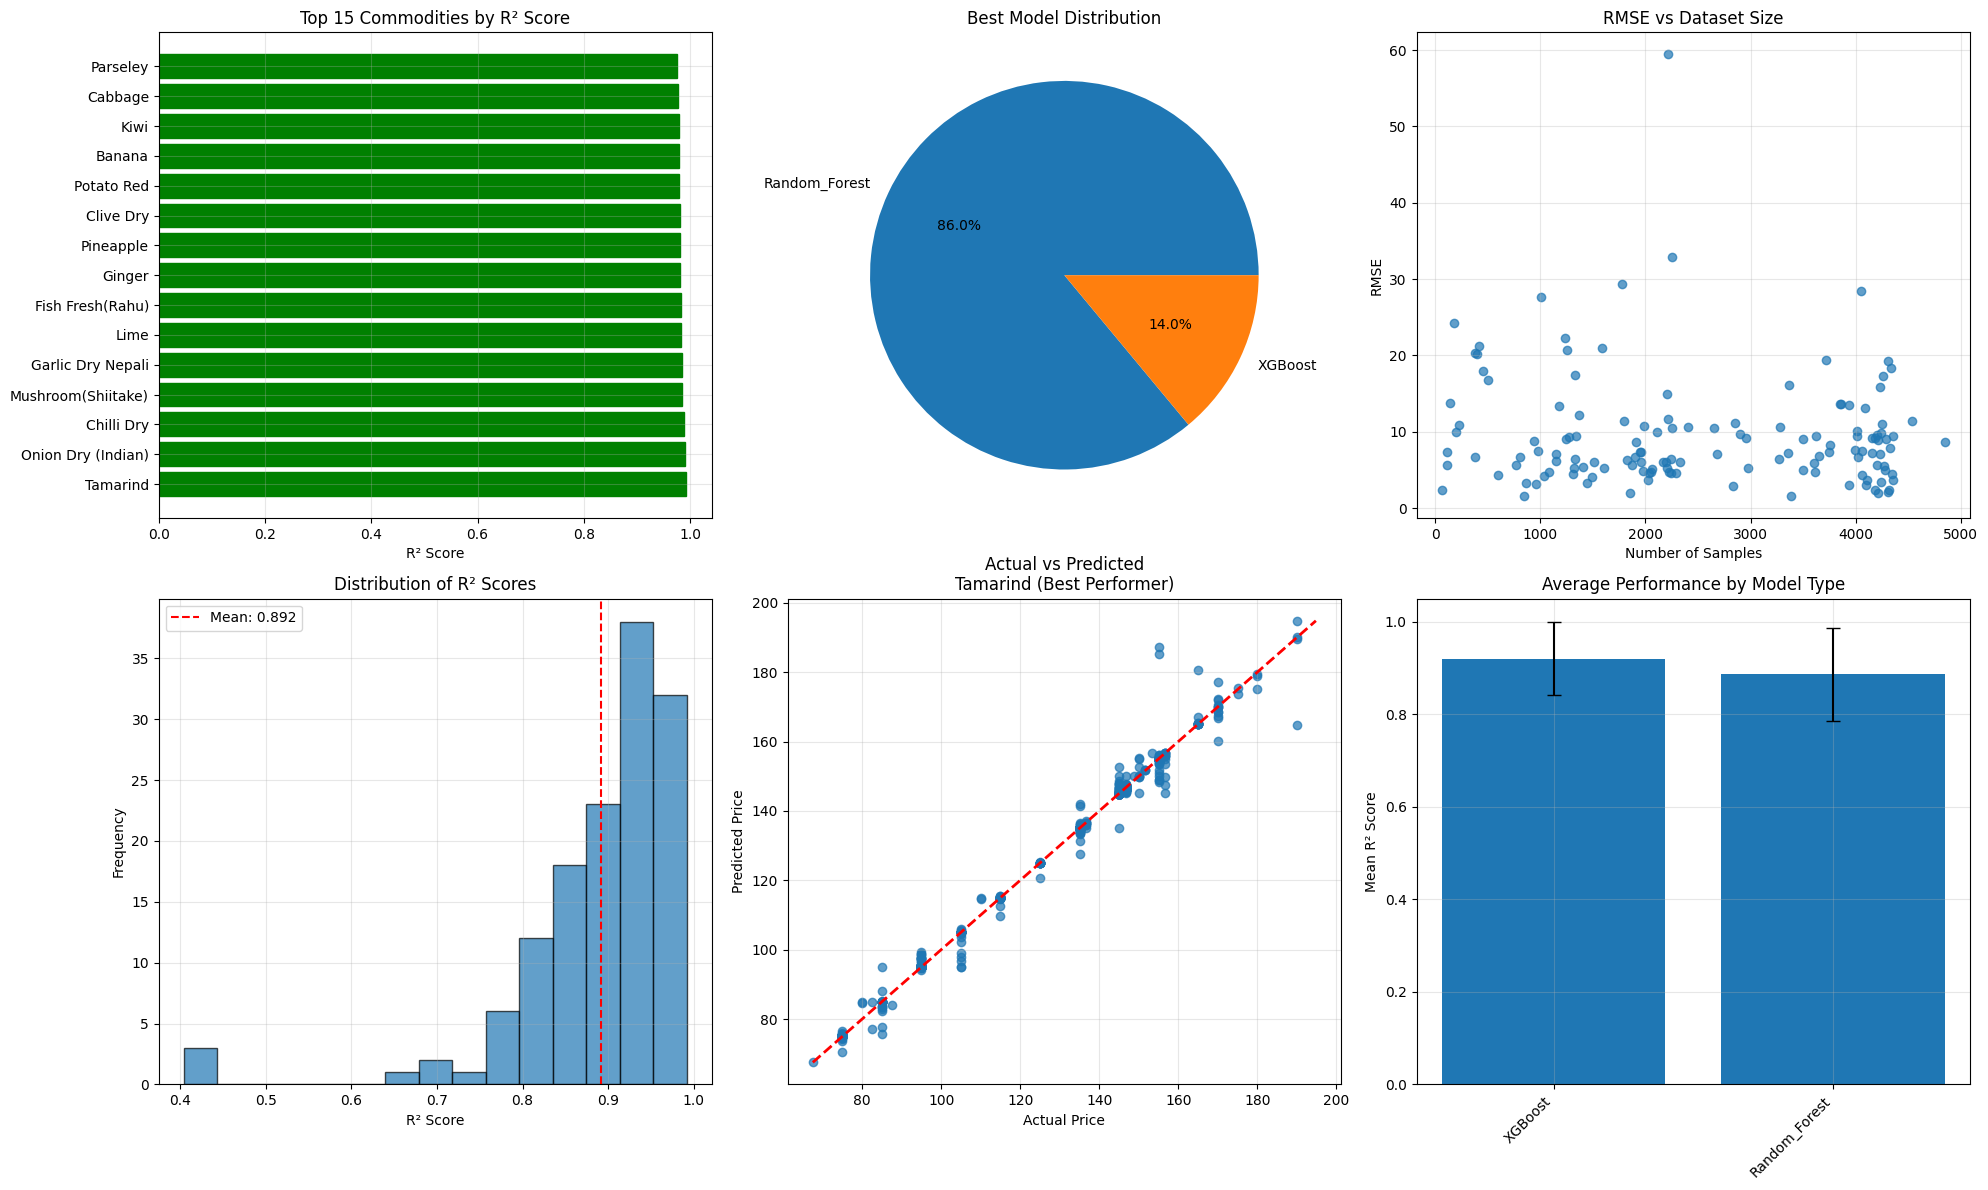

In [12]:
create_visualizations(commodity_results, summary_df)

In [13]:
summary_df

,Commodity,Best_Model,R2_Score,RMSE,MAPE,Samples,Price_Range,Avg_Price
46,Tamarind,Random_Forest,0.991926,2.417417,0.005316,4314,55.0-213.3,127.674379
4,Onion Dry (Indian),Random_Forest,0.990201,2.412283,0.023027,4182,17.5-121.0,49.197066
64,Chilli Dry,XGBoost,0.989003,9.399252,0.012846,4352,42.5-500.0,304.703642
135,Mushroom(Shiitake),Random_Forest,0.984181,10.950364,0.007522,226,743.3-1050.0,813.637434
70,Garlic Dry Nepali,Random_Forest,0.984050,9.406616,0.026009,4011,52.5-355.0,166.178417
...,...,...,...,...,...,...,...,...
95,Mushroom(Button),Random_Forest,0.694316,32.837925,0.071258,2253,200.0-500.0,333.697226
85,Mandarin,XGBoost,0.659852,16.736034,0.032748,501,150.0-310.0,230.149701
30,Mustard Leaf,Random_Forest,0.435885,9.147193,0.110685,4156,12.5-80.0,46.588693
37,Sugarbeet,Random_Forest,0.404793,11.368040,0.110609,4535,25.0-105.0,68.411755


In [21]:
a = load_models(filename='commodity_price_models.pkl')